<a href="https://colab.research.google.com/github/T1050/student-performance-predictor/blob/main/student-performance-predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA ANALYSIS


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
data = pd.read_csv('student_performance_realistic_data.csv')


In [4]:
data.head()

,student_id,student_name,fathers_name,attendance_rate,weekly_study_hours,previous_semester_score,sleep_hours_per_night,extracurricular_activities,parental_education_level,internet_access_at_home,distance_from_school,part_time_job,learning_disability,final_score,passed
0,1,Sofia Harris,Henry Harris,89.929664,32,89.809059,4.0,0,1,1,0,0,0,72.31,1
1,2,Mia Hill,Amelia Hill,NaN,4,96.895092,5.0,1,0,0,0,0,0,64.51,1
2,3,Ava Gupta,Mason Gupta,92.843697,33,58.276141,9.0,0,0,1,1,1,0,71.98,1
3,4,Sofia Thomas,Isha Thomas,55.882199,39,55.870948,NaN,0,1,1,0,1,0,49.09,0
4,5,Mason Rodriguez,Benjamin Rodriguez,86.986517,10,56.793559,8.0,1,2,1,2,0,0,76.27,1


In [5]:
data.tail()

,student_id,student_name,fathers_name,attendance_rate,weekly_study_hours,previous_semester_score,sleep_hours_per_night,extracurricular_activities,parental_education_level,internet_access_at_home,distance_from_school,part_time_job,learning_disability,final_score,passed
996,997,Evelyn Hill,Avery Hill,60.201233,33,60.353218,9.0,1,1,0,0,0,0,64.20,1
997,998,Michael Lee,Jacob Lee,82.699705,9,72.675727,5.0,1,1,1,2,0,0,53.56,0
998,999,Emily Wright,Aria Wright,90.918478,34,42.464090,9.0,1,2,1,2,1,0,64.07,1
999,1000,Elizabeth Hill,Avery Hill,52.500929,10,84.689505,NaN,1,1,1,1,0,0,63.46,1
1000,1001,Mason Flores,Aditya Flores,95.576065,10,66.757333,4.0,1,0,1,2,0,0,62.23,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1001 non-null   int64  
 1   student_name                1001 non-null   object 
 2   fathers_name                1001 non-null   object 
 3   attendance_rate             951 non-null    float64
 4   weekly_study_hours          1001 non-null   int64  
 5   previous_semester_score     971 non-null    float64
 6   sleep_hours_per_night       961 non-null    float64
 7   extracurricular_activities  1001 non-null   int64  
 8   parental_education_level    1001 non-null   int64  
 9   internet_access_at_home     1001 non-null   int64  
 10  distance_from_school        1001 non-null   int64  
 11  part_time_job               1001 non-null   int64  
 12  learning_disability         1001 non-null   int64  
 13  final_score                 1001 

DATA CLEANING

In [9]:
data.columns

Index(['student_id', 'student_name', 'fathers_name', 'attendance_rate',
       'weekly_study_hours', 'previous_semester_score',
       'sleep_hours_per_night', 'extracurricular_activities',
       'parental_education_level', 'internet_access_at_home',
       'distance_from_school', 'part_time_job', 'learning_disability',
       'final_score', 'passed'],
      dtype='object')

In [10]:
#remove unwanted columns
data.drop(['sleep_hours_per_night','extracurricular_activities','parental_education_level','distance_from_school', 'part_time_job'], axis=1, inplace=True)

In [11]:
data.columns

Index(['student_id', 'student_name', 'fathers_name', 'attendance_rate',
       'weekly_study_hours', 'previous_semester_score',
       'internet_access_at_home', 'learning_disability', 'final_score',
       'passed'],
      dtype='object')

In [12]:
pd.isnull(data)

,student_id,student_name,fathers_name,attendance_rate,weekly_study_hours,previous_semester_score,internet_access_at_home,learning_disability,final_score,passed
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
996,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False
999,False,False,False,False,False,False,False,False,False,False


In [13]:
pd.isnull(data).sum()

,0
student_id,0
student_name,0
fathers_name,0
attendance_rate,50
weekly_study_hours,0
previous_semester_score,30
internet_access_at_home,0
learning_disability,0
final_score,0
passed,0


In [14]:
data.shape

(1001, 10)

In [15]:
#drop null values
data.dropna(inplace=True)

In [16]:
data.shape

(923, 10)

In [17]:
pd.isnull(data).sum()

,0
student_id,0
student_name,0
fathers_name,0
attendance_rate,0
weekly_study_hours,0
previous_semester_score,0
internet_access_at_home,0
learning_disability,0
final_score,0
passed,0


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 923 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               923 non-null    int64  
 1   student_name             923 non-null    object 
 2   fathers_name             923 non-null    object 
 3   attendance_rate          923 non-null    float64
 4   weekly_study_hours       923 non-null    int64  
 5   previous_semester_score  923 non-null    float64
 6   internet_access_at_home  923 non-null    int64  
 7   learning_disability      923 non-null    int64  
 8   final_score              923 non-null    float64
 9   passed                   923 non-null    int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 79.3+ KB


In [21]:
data.columns

Index(['student_id', 'student_name', 'fathers_name', 'attendance_rate',
       'weekly_study_hours', 'previous_semester_score',
       'internet_access_at_home', 'learning_disability', 'final_score',
       'passed'],
      dtype='object')

In [27]:
# rename column
data.rename(columns={
    'student_id':'ID'
}, inplace=True)

In [28]:
data.columns

Index(['ID', 'student_name', 'fathers_name', 'attendance_rate',
       'weekly_study_hours', 'previous_semester_score',
       'internet_access_at_home', 'learning_disability', 'final_score',
       'passed'],
      dtype='object')

EDA (Exploratory Data Analysis)

In [30]:
data.describe()

,ID,attendance_rate,weekly_study_hours,previous_semester_score,internet_access_at_home,learning_disability,final_score,passed
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,498.538462,75.420684,19.591549,69.338385,0.895991,0.111593,62.292394,0.574215
std,288.676683,14.499758,11.410361,17.462817,0.305437,0.315035,15.048342,0.494730
min,1.000000,50.009420,0.000000,40.011192,0.000000,0.000000,16.800000,0.000000
25%,248.500000,62.694899,10.000000,54.027169,1.000000,0.000000,51.555000,0.000000
50%,496.000000,76.361633,19.000000,68.971076,1.000000,0.000000,62.540000,1.000000
75%,744.500000,88.011644,29.000000,84.662959,1.000000,0.000000,72.920000,1.000000
max,1001.000000,99.985690,39.000000,99.814553,1.000000,1.000000,100.000000,1.000000


Overall Pass vs. Fail Count

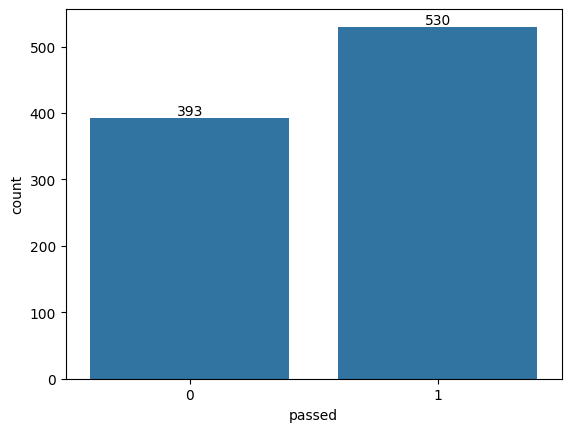

In [32]:
ax = sns.countplot(x='passed', data=data)
for bars in ax.containers:
    ax.bar_label(bars)

Average Final Score by Study Hours Bracket

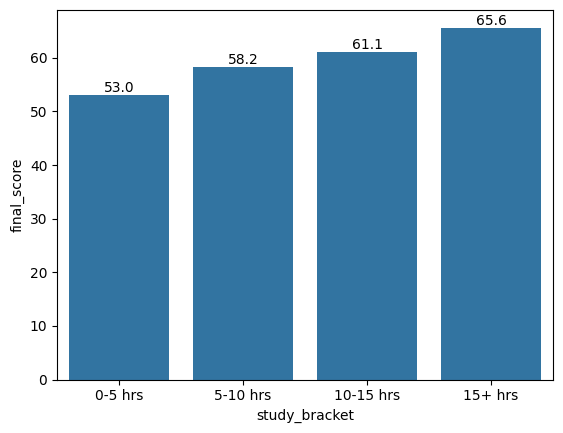

In [33]:
# Group study hours into ranges
data['study_bracket'] = pd.cut(
    data['weekly_study_hours'],
    bins=[0, 5, 10, 15, 40],
    labels=['0-5 hrs', '5-10 hrs', '10-15 hrs', '15+ hrs']
)

ax = sns.barplot(x='study_bracket', y='final_score', data=data, errorbar=None)
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.1f')